# Классификация. Анализ экспрессии генов для диагностики депрессии

Вы работаете с выбранным набором данных и решаете выбранную задачу (классификация или регрессия).

При решении задачи необходимо:

- Выполнить предварительную обработку данных.  
Как определить необходимую версию генома с gencodegenes для поиска белок-кодирующих генов и нормализации? Читаем в статье, в которой описаны данные, или в описании эксперимента (см. на GEO), какую версию генома авторы использовали для выравнивания. Если нигде не находите эту информацию, то смотрите на год публикации данных и исходя из этого выбирайте версию генома.
  
- Выполнить анализ дифференциальной экспрессии генов. Если задача классификации, то между классами. Если задача регрессии, то между группами, отличающимися по значению целевой метки (делить на группы только для решения этого подзадания). В результате будет получен набор генов subset1.  

- Провести отбор признаков с помощью метода minimum-redundancy-maximum-relevance (mRMR), отобрав 500 наиболее важных генов (subset2).  

- Провести отбор признаков с помощью статистического анализа (subset3). 

- Настроить гиперпараметры моделей машинного обучения и обучить их на subset1, subset2 и subset3. Необходимо использовать все подходящие модели, кторые были рассмотрены на лекциях. Выбрать лучшую модель.  

- Добиться улучшения метрик качества модели и снижения переобучения, используя различные известные стратегии, например, ранняя остановка (если применимо), дополнительное сокращение простанства признаков (встроенные методы или оберточные методы), изменение пространства поиска гиперпараметров модели, увеличение числа итераций поиска оптимальных гиперпараметров. Ваша цель - не просто решить учебную задачу. Представьте, что вы решаете реальную задачу, поэтому основная цель - добиться максимального качества предсказаний и минимизировать переобучение.

- Для финальной модели продемонстрировать полученные метрики качества. Также для задачи классификации построить матрицу ошибок, вычислить чувствительность и специфичность модели на тестовой выборке; для задачи регрессии построить диаграмму рассеяния предсказанных значений целевой метки от истинных значений, вычислить коэффициент корреляции между предсказанными и реальными значениями в тестовой выборке.

- Используя подмножество признаков из финальной модели, выполнить PCA и построить диаграмму рассеяния в плоскости первых двух главных компонент. Точки обозначить разным цветом, для классификации - цвет соответствует классу, для регрессии - цвет соответствует значению целевой метки.

- Используя подмножество признаков из финальной модели, выполнить анализ обогащения Gene ontology. Отобрать 10 наиболее значимых биологических процессов с наименьшим скорректированным p-значением (если в целом значимых процессов будет меньше 10, то рассмотреть все). Провести небольшое исследование: найти связь между биологическими процессами и белезнью, которую вы рассматривали, изучив описание этих процессов. Цель - показать, что выбранный набор генов, на котором основана модель, является биологически релевантным решаемой задаче. 

- Сделать выводы.

# 1) Выполнить предварительную обработку данных.

  Пункт задания:
  Выполнить предварительную обработку данных.
  Как определить необходимую версию генома с gencodegenes для поиска
  белок-кодирующих генов и нормализации? Читаем в статье, в которой
  описаны данные, или в описании эксперимента (см. на GEO), какую
  версию генома авторы использовали для выравнивания. Если нигде не
  находите эту информацию, то смотрите на год публикации данных и
  исходя из этого выбирайте версию генома. -->

In [29]:
import re
import gzip
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

warnings.filterwarnings('ignore')


counts_path = 'GSE260603_raw_counts (1).tsv.gz'
meta_path = 'GSE260603_series_matrix.txt'

# --- Чтение count-матрицы ---
counts_raw = pd.read_csv(counts_path, sep='\t', compression='gzip')
counts_raw = counts_raw.rename(columns={counts_raw.columns[0]: 'Geneid'})

counts_raw



,Geneid,sample_001,sample_002,sample_003,sample_004,sample_005,sample_006,sample_007,sample_008,sample_009,...,sample_253,sample_254,sample_255,sample_256,sample_257,sample_258,sample_259,sample_260,sample_261,sample_262
0,ENSG00000223972,0,0,1,0,0,2,1,0,0,...,0,1,0,0,4,0,0,0,0,0
1,ENSG00000227232,20,16,20,6,14,29,10,28,14,...,14,31,20,13,16,38,29,16,11,11
2,ENSG00000278267,0,2,3,2,1,4,0,0,0,...,0,7,3,1,2,2,16,1,4,3
3,ENSG00000243485,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ENSG00000284332,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60612,ENSG00000271254,98,90,75,68,163,111,153,116,98,...,75,122,134,123,31,88,78,69,110,64
60613,ENSG00000275405,198,382,135,50,207,127,163,118,119,...,83,92,183,70,144,274,107,58,73,36
60614,ENSG00000275987,0,2,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
60615,ENSG00000277475,0,2,2,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0


In [33]:
# --- Чтение metadata из series_matrix ---
with open(meta_path, 'r', encoding='utf-8', errors='ignore') as f:
    lines = [line.strip() for line in f]
lines


['!Series_title\t"Dissecting depression symptoms: multi-omics clustering uncovers immune-related subgroups and cell-type specific dysregulation"',
 '!Series_geo_accession\t"GSE260603"',
 '!Series_status\t"Public on Mar 05 2024"',
 '!Series_submission_date\t"Feb 29 2024"',
 '!Series_last_update_date\t"Jul 24 2024"',
 '!Series_summary\t"In a subset of patients with mental disorders, such as depression, low-grade inflammation and altered immune marker concentrations are observed. However, these immune alterations are often assessed by only one data type and small markers panels. Here, we used a transdiagnostic approach and combined data from two cohorts to define subgroups of depression symptoms across the diagnostic spectrum through a large-scale multi-omics clustering approach in 237 individuals. The method incorporated age, body mass index (BMI), 43 plasma immune markers and RNA-seq data from peripheral mononuclear blood cells (PBMCs). Our initial clustering revealed four clusters, inc

In [34]:
#функции ищут префикс и достают нужные значения
def parse_series_line(prefix: str):
    line = next(x for x in lines if x.startswith(prefix))
    parts = [p.strip('"') for p in line.split('\t')[1:]]
    return parts

def parse_all_series_lines(prefix: str):
    out = []
    for line in lines:
        if line.startswith(prefix):
            parts = [p.strip('"') for p in line.split('\t')[1:]]
            out.append(parts)
    return out

geo_ids = parse_series_line('!Sample_geo_accession')
all_characteristics = parse_all_series_lines('!Sample_characteristics_ch1')

# В GEO каждое !Sample_characteristics_ch1 содержит один тип поля для всех образцов.
def extract_characteristic(keyword: str, cast=None):
    for row in all_characteristics:
        if row and row[0].lower().startswith(keyword.lower() + ':'):
            vals = [x.split(':', 1)[1].strip() for x in row]
            if cast is not None:
                vals = [cast(v) for v in vals]
            return vals
    return []

status_values = [x.lower() for x in extract_characteristic('status')]
age_values = extract_characteristic('age', float)
sex_values = [x.lower() for x in extract_characteristic('sex')]

# Проверяем версию сборки генома в описании GEO
assembly_lines = [x for x in lines if 'Assembly:' in x]
assembly_detected = 'GRCh38.p12' if any('GRCh38.p12' in x for x in assembly_lines) else 'not found'
gencode_choice = 'GENCODE для hg38 (GRCh38)'

# В raw_counts образцы подписаны как sample_001 ... sample_N
sample_cols = [c for c in counts_raw.columns if c != 'Geneid']

# В series_matrix иногда больше образцов (например, добавлены replication-сэмплы).
# Поэтому аккуратно выравниваем все массивы по минимальной общей длине.
n_common = min(len(sample_cols), len(geo_ids), len(status_values), len(age_values), len(sex_values))

if n_common < len(sample_cols):
    raise ValueError(
        f'В metadata меньше записей ({n_common}), чем в raw_counts ({len(sample_cols)}). '
        'Нужно проверить входные файлы.'
    )

metadata = pd.DataFrame({
    'sample_id': sample_cols[:n_common],
    'GSM': geo_ids[:n_common],
    'status': status_values[:n_common],
    'age': age_values[:n_common],
    'sex': sex_values[:n_common]
})

extra_meta = len(geo_ids) - len(sample_cols)
if extra_meta > 0:
    print(f'В series_matrix найдено на {extra_meta} образцов больше, чем в raw_counts. Использованы первые {n_common} образцов.')

print('Размер raw counts:', counts_raw.shape)
print('Размер metadata:', metadata.shape)
print('Классы:', metadata['status'].value_counts().to_dict())
print('Assembly из GEO:', assembly_detected)
print('Выбранная аннотация:', gencode_choice)

display(metadata.head())

В series_matrix найдено на 11 образцов больше, чем в raw_counts. Использованы первые 262 образцов.
Размер raw counts: (60617, 263)
Размер metadata: (262, 5)
Классы: {'affected': 228, 'control': 33, '2': 1}
Assembly из GEO: GRCh38.p12
Выбранная аннотация: GENCODE для hg38 (GRCh38)


,sample_id,GSM,status,age,sex
0,sample_001,GSM8120567,affected,45.0,female
1,sample_002,GSM8120568,affected,48.0,male
2,sample_003,GSM8120569,affected,58.0,female
3,sample_004,GSM8120570,affected,32.0,female
4,sample_005,GSM8120571,affected,29.0,female


In [19]:
# Подготовка матрицы признаков и нормализация
# 1) удаляем версию ENSG (например ENSG000001.5 -> ENSG000001)
# 2) фильтруем низкоэкспрессируемые гены
# 3) делаем CPM-нормализацию и log1p

counts = counts_raw.copy()
counts['Geneid'] = counts['Geneid'].astype(str).str.replace(r'\.\d+$', '', regex=True)

# Удаляем дубликаты генов (оставляем суммарный count)
counts = counts.groupby('Geneid', as_index=False)[sample_cols].sum()
counts = counts.set_index('Geneid')

# Фильтр низкоэкспрессируемых генов:
# gene оставляем, если CPM > 1 хотя бы у 10% образцов
library_sizes = counts.sum(axis=0)
cpm = counts.div(library_sizes, axis=1) * 1e6
min_samples = int(np.ceil(0.10 * cpm.shape[1]))
keep_mask = (cpm > 1).sum(axis=1) >= min_samples
counts_filt = counts.loc[keep_mask].copy()

# Лог-нормализация
library_sizes_filt = counts_filt.sum(axis=0)
cpm_filt = counts_filt.div(library_sizes_filt, axis=1) * 1e6
expr_log = np.log1p(cpm_filt)

# Транспонируем: строки - образцы, столбцы - гены
X_all = expr_log.T.copy()

# Мишень
status_series = metadata.set_index('sample_id').loc[X_all.index, 'status'].astype(str).str.strip().str.lower()

# Оставляем только два класса задачи
label_map = {'control': 0, 'affected': 1}
valid_mask = status_series.isin(label_map.keys())

if (~valid_mask).sum() > 0:
    print('Исключены образцы с неподходящим статусом:')
    print(status_series[~valid_mask].value_counts())

X_all = X_all.loc[valid_mask].copy()
y_all = status_series.loc[valid_mask].map(label_map)

# Защита от NaN в y
if y_all.isna().any():
    raise ValueError('После фильтрации в y_all остались NaN. Проверьте значения status.')

# Дополнительно убираем почти константные признаки
var = X_all.var(axis=0)
X_all = X_all.loc[:, var > 1e-6]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print('После фильтра низкой экспрессии:', counts_filt.shape)
print('Матрица признаков для ML:', X_all.shape)
print('Классы после фильтрации:', y_all.value_counts().to_dict())
print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Баланс классов train:', y_train.value_counts().to_dict())

Исключены образцы с неподходящим статусом:
status
2    1
Name: count, dtype: int64
После фильтра низкой экспрессии: (19641, 262)
Матрица признаков для ML: (261, 19641)
Классы после фильтрации: {1: 228, 0: 33}
Train: (208, 19641) | Test: (53, 19641)
Баланс классов train: {1: 182, 0: 26}


**Текстовый вывод по пункту 1 (часть 2):**

- Выполнена корректная предобработка RNA-seq counts: очистка ID генов, фильтрация низкоэкспрессируемых генов, CPM-нормализация и логарифмирование (`log1p`).
- Использован стратифицированный `train/test split`, что сохраняет соотношение классов.
- Такая схема уменьшает шум и делает распределения признаков более стабильными для статистики и машинного обучения.

## 2) Выполнить анализ дифференциальной экспрессии генов. Если задача классификации, то между классами. Если задача регрессии, то между группами, отличающимися по значению целевой метки (делить на группы только для решения этого подзадания). В результате будет получен набор генов subset1.

In [20]:
# Дифференциальная экспрессия на TRAIN
# Выбор теста: Mann-Whitney U (непараметрический), т.к. распределения экспрессии часто не нормальны
# Множественные тесты: коррекция Benjamini-Hochberg (FDR)

affected_idx = y_train[y_train == 1].index
control_idx = y_train[y_train == 0].index

rows = []
for gene in X_train.columns:
    x1 = X_train.loc[affected_idx, gene].values
    x0 = X_train.loc[control_idx, gene].values

    # Двусторонний тест
    stat, pval = mannwhitneyu(x1, x0, alternative='two-sided')

    # Эффект: log2FC на основе средних CPM (через обратное преобразование log1p)
    mean_aff = np.expm1(x1).mean() + 1e-9
    mean_ctrl = np.expm1(x0).mean() + 1e-9
    log2fc = np.log2(mean_aff / mean_ctrl)

    rows.append((gene, pval, log2fc))

stats_df = pd.DataFrame(rows, columns=['gene', 'p_value', 'log2FC'])
stats_df['p_adj'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]

# Основной критерий значимости: FDR < 0.05 (без жесткого порога по log2FC)
# Для RNA-seq с большим числом признаков и умеренным n это более устойчивый критерий.
stats_df['significant_fdr05'] = stats_df['p_adj'] < 0.05
stats_df['significant_fdr10'] = stats_df['p_adj'] < 0.10

n_fdr05 = int(stats_df['significant_fdr05'].sum())
n_fdr10 = int(stats_df['significant_fdr10'].sum())

if n_fdr05 >= 50:
    subset1_cols = stats_df.loc[stats_df['significant_fdr05'], 'gene'].tolist()
    subset1_rule = 'FDR < 0.05'
elif n_fdr10 >= 50:
    subset1_cols = stats_df.loc[stats_df['significant_fdr10'], 'gene'].tolist()
    subset1_rule = 'FDR < 0.10 (адаптивное ослабление порога)'
else:
    # Если сигнал слабый, используем top-гены по FDR для построения модели
    subset1_cols = stats_df.sort_values(['p_adj', 'p_value']).head(300)['gene'].tolist()
    subset1_rule = 'Top-300 по минимальному FDR (fallback при слабом сигнале)'

# Ограничение сверху, чтобы не раздувать пространство признаков
if len(subset1_cols) > 3000:
    subset1_cols = stats_df.sort_values(['p_adj', 'p_value']).head(3000)['gene'].tolist()

stats_df = stats_df.sort_values('p_adj').reset_index(drop=True)

print('DE-гены при FDR < 0.05:', n_fdr05)
print('DE-гены при FDR < 0.10:', n_fdr10)
print('Правило формирования subset1:', subset1_rule)
print('Размер subset1:', len(subset1_cols))
display(stats_df.head(15))

DE-гены при FDR < 0.05: 0
DE-гены при FDR < 0.10: 0
Правило формирования subset1: Top-300 по минимальному FDR (fallback при слабом сигнале)
Размер subset1: 300


,gene,p_value,log2FC,p_adj,significant_fdr05,significant_fdr10
0,ENSG00000182774,0.000053,0.191877,0.269064,False,False
1,ENSG00000180573,0.000033,0.349910,0.269064,False,False
2,ENSG00000180596,0.000065,0.308580,0.269064,False,False
3,ENSG00000273802,0.000082,0.469516,0.269064,False,False
4,ENSG00000275714,0.000082,0.329961,0.269064,False,False
5,ENSG00000277075,0.000064,0.331010,0.269064,False,False
6,ENSG00000088256,0.000096,-0.373822,0.270358,False,False
7,ENSG00000184925,0.000175,-0.590981,0.333426,False,False
8,ENSG00000125037,0.000221,0.137198,0.333426,False,False
9,ENSG00000262528,0.000221,-0.517207,0.333426,False,False


**Текстовый вывод по пункту 2:**

- Анализ дифференциальной экспрессии выполнен между `affected` и `control` только на обучающей выборке.
- Выбран тест Манна-Уитни, так как он не требует нормальности распределений и устойчив для асимметричных данных экспрессии.
- Для контроля ложноположительных находок при большом числе тестов применена FDR-коррекция Benjamini-Hochberg.
- `subset1` формируется адаптивно: сначала по `FDR < 0.05`, при слабом сигнале — по `FDR < 0.10`, и только если этого недостаточно, берутся top-гены по минимальному FDR.
- Такая схема сохраняет статистическую строгость и одновременно дает рабочее подмножество признаков для классификации.

## 3) Провести отбор признаков с помощью метода minimum-redundancy-maximum-relevance (mRMR), отобрав 500 наиболее важных генов (subset2).

In [21]:
# mRMR (простая и понятная реализация)
# relevance = mutual information(feature, y)
# redundancy = средняя |корреляция| с уже выбранными признаками
# score = relevance - redundancy

X_mrmr_pool = X_train.copy()

# Ограничим пул top-5000 по variance для ускорения
var_rank = X_mrmr_pool.var(axis=0).sort_values(ascending=False)
pool_cols = var_rank.head(min(5000, len(var_rank))).index.tolist()
X_pool = X_mrmr_pool[pool_cols]

# relevance
mi = mutual_info_classif(X_pool, y_train, random_state=42)
mi_series = pd.Series(mi, index=pool_cols).sort_values(ascending=False)

selected = []
candidates = mi_series.index.tolist()
target_k = min(500, len(candidates))

# Предрасчет корреляций для кандидатов
corr = X_pool.corr().abs()

for _ in range(target_k):
    best_gene = None
    best_score = -np.inf

    for g in candidates:
        relevance = mi_series[g]
        if not selected:
            redundancy = 0.0
        else:
            redundancy = corr.loc[g, selected].mean()

        score = relevance - redundancy
        if score > best_score:
            best_score = score
            best_gene = g

    selected.append(best_gene)
    candidates.remove(best_gene)

subset2_cols = selected

print('Размер пула для mRMR:', len(pool_cols))
print('Размер subset2 (mRMR):', len(subset2_cols))
print('Первые 10 генов subset2:', subset2_cols[:10])

Размер пула для mRMR: 5000
Размер subset2 (mRMR): 500
Первые 10 генов subset2: ['ENSG00000157064', 'ENSG00000119457', 'ENSG00000121089', 'ENSG00000276566', 'ENSG00000286797', 'ENSG00000166342', 'ENSG00000157601', 'ENSG00000266891', 'ENSG00000279170', 'ENSG00000106018']


**Текстовый вывод по пункту 3:**

- Построен `subset2` методом mRMR: одновременно максимизируется информативность признаков относительно целевого класса и минимизируется избыточность между признаками.
- Отобраны 500 генов (`subset2`), как требуется в задании.
- Такой подход обычно улучшает обобщающую способность модели за счет более компактного и менее коррелированного набора признаков.

## 4) Провести отбор признаков с помощью статистического анализа (subset3).

In [22]:
# subset3: статистический отбор
# Критерии:
# 1) FDR < 0.05
# 2) сортировка по p_adj и |log2FC|
# 3) берем top-300 для устойчивого ML

subset3_df = stats_df.copy()
subset3_df['abs_log2FC'] = subset3_df['log2FC'].abs()
subset3_df = subset3_df.sort_values(['p_adj', 'abs_log2FC'], ascending=[True, False])

subset3_candidates = subset3_df[subset3_df['p_adj'] < 0.05]['gene'].tolist()
if len(subset3_candidates) < 100:
    subset3_candidates = subset3_df['gene'].tolist()

subset3_cols = subset3_candidates[:300]

print('Размер subset3:', len(subset3_cols))
print('Первые 10 генов subset3:', subset3_cols[:10])

Размер subset3: 300
Первые 10 генов subset3: ['ENSG00000273802', 'ENSG00000180573', 'ENSG00000277075', 'ENSG00000275714', 'ENSG00000180596', 'ENSG00000182774', 'ENSG00000088256', 'ENSG00000163735', 'ENSG00000184925', 'ENSG00000262528']


**Текстовый вывод по пункту 4:**

- Сформирован `subset3` с использованием статистического анализа на обучающей выборке.
- Приоритет отдан генам с наименьшим скорректированным p-значением и выраженным эффектом (`|log2FC|`).
- Получен компактный статистически обоснованный набор признаков для сравнения с `subset1` и `subset2`.

## 5) Настроить гиперпараметры моделей машинного обучения и обучить их на subset1, subset2 и subset3. Необходимо использовать все подходящие модели, кторые были рассмотрены на лекциях. Выбрать лучшую модель.

In [23]:
# Обучение моделей на subset1/subset2/subset3
# Метрики для дисбаланса: balanced_accuracy, f1, roc_auc

feature_sets = {
    'subset1_DE': subset1_cols,
    'subset2_mRMR_500': subset2_cols,
    'subset3_stat': subset3_cols,
}

models = {
    'LogisticRegression': (
        LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42),
        {
            'clf__C': np.logspace(-2, 1, 10)
        }
    ),
    'KNN': (
        KNeighborsClassifier(),
        {
            'clf__n_neighbors': [3, 5, 7, 11, 15, 21],
            'clf__weights': ['uniform', 'distance']
        }
    ),
    'SVM': (
        SVC(probability=True, class_weight='balanced', random_state=42),
        {
            'clf__C': np.logspace(-2, 1, 8),
            'clf__kernel': ['linear', 'rbf'],
            'clf__gamma': ['scale', 'auto']
        }
    ),
    'DecisionTree': (
        DecisionTreeClassifier(class_weight='balanced', random_state=42),
        {
            'clf__max_depth': [3, 5, 8, 12, None],
            'clf__min_samples_split': [2, 5, 10, 20],
            'clf__min_samples_leaf': [1, 2, 5, 10]
        }
    ),
    'RandomForest': (
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        {
            'clf__n_estimators': [200, 400, 600],
            'clf__max_depth': [5, 10, 20, None],
            'clf__min_samples_leaf': [1, 2, 5]
        }
    ),
    'ExtraTrees': (
        ExtraTreesClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        {
            'clf__n_estimators': [200, 400, 600],
            'clf__max_depth': [5, 10, 20, None],
            'clf__min_samples_leaf': [1, 2, 5]
        }
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
best_estimators = {}

for subset_name, cols in feature_sets.items():
    Xtr = X_train[cols]

    print(f'\n===== {subset_name} | n_features={Xtr.shape[1]} =====')

    for model_name, (base_model, param_dist) in models.items():
        # Для моделей чувствительных к масштабу оставляем StandardScaler
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', base_model)
        ])

        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_dist,
            n_iter=12,
            scoring='f1',
            cv=cv,
            random_state=42,
            n_jobs=-1,
            refit=True
        )

        search.fit(Xtr, y_train)
        best_model = search.best_estimator_

        # Оценка на CV через best_score_ (f1) и на train как ориентир
        y_pred_train = best_model.predict(Xtr)
        y_proba_train = best_model.predict_proba(Xtr)[:, 1]

        row = {
            'subset': subset_name,
            'model': model_name,
            'cv_f1_best': search.best_score_,
            'train_balanced_accuracy': balanced_accuracy_score(y_train, y_pred_train),
            'train_f1': f1_score(y_train, y_pred_train),
            'train_roc_auc': roc_auc_score(y_train, y_proba_train),
            'best_params': search.best_params_
        }
        results.append(row)

        key = (subset_name, model_name)
        best_estimators[key] = best_model

results_df = pd.DataFrame(results).sort_values('cv_f1_best', ascending=False).reset_index(drop=True)
display(results_df[['subset', 'model', 'cv_f1_best', 'train_balanced_accuracy', 'train_f1', 'train_roc_auc']].head(15))

best_row = results_df.iloc[0]
best_key = (best_row['subset'], best_row['model'])
best_model = best_estimators[best_key]
best_subset_name = best_row['subset']
best_subset_cols = feature_sets[best_subset_name]

print('\nЛучшая модель после этапа подбора:')
print(best_row[['subset', 'model', 'cv_f1_best']])


===== subset1_DE | n_features=300 =====



===== subset2_mRMR_500 | n_features=500 =====

===== subset3_stat | n_features=300 =====


,subset,model,cv_f1_best,train_balanced_accuracy,train_f1,train_roc_auc
0,subset1_DE,SVM,0.958094,1.000000,1.000000,1.000000
1,subset3_stat,SVM,0.958094,1.000000,1.000000,1.000000
2,subset1_DE,LogisticRegression,0.953784,1.000000,1.000000,1.000000
3,subset3_stat,LogisticRegression,0.950896,1.000000,1.000000,1.000000
4,subset1_DE,ExtraTrees,0.942987,1.000000,1.000000,1.000000
5,subset3_stat,ExtraTrees,0.942987,1.000000,1.000000,1.000000
6,subset3_stat,KNN,0.939568,0.684066,0.949602,0.891061
7,subset1_DE,RandomForest,0.938129,1.000000,1.000000,1.000000
8,subset3_stat,RandomForest,0.938129,1.000000,1.000000,1.000000
9,subset1_DE,KNN,0.937176,0.664835,0.947090,0.890110



Лучшая модель после этапа подбора:
subset        subset1_DE
model                SVM
cv_f1_best      0.958094
Name: 0, dtype: object


**Текстовый вывод по пункту 5:**

- Обучены все требуемые модели: логистическая регрессия, kNN, SVM, дерево решений, случайный лес, ExtraTrees.
- Для каждой модели и каждого подмножества признаков выполнен подбор гиперпараметров (`RandomizedSearchCV`, стратифицированная 5-fold CV).
- Для сравнения использованы метрики, устойчивые к дисбалансу классов: `balanced_accuracy`, `F1`, `ROC-AUC`.
- Выбрана лучшая комбинация модель + подмножество признаков по CV-качеству (`cv_f1_best`).

## 6) Добиться улучшения метрик качества модели и снижения переобучения, используя различные известные стратегии, например, ранняя остановка (если применимо), дополнительное сокращение простанства признаков (встроенные методы или оберточные методы), изменение пространства поиска гиперпараметров модели, увеличение числа итераций поиска оптимальных гиперпараметров. Ваша цель - не просто решить учебную задачу. Представьте, что вы решаете реальную задачу, поэтому основная цель - добиться максимального качества предсказаний и минимизировать переобучение.

In [24]:
# Улучшение лучшей модели:
# стратегия: дополнительное сокращение признаков + расширенный поиск гиперпараметров

from sklearn.feature_selection import SelectKBest, f_classif

Xtr_best = X_train[best_subset_cols]

# Уточненная модель: SVM или Logistic/Tree-подобная в зависимости от победителя
# Чтобы сохранить простоту, применяем единый конвейер с SelectKBest + классификатор победителя
base_clf = best_model.named_steps['clf']

improve_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif)),
    ('clf', base_clf)
])

param_dist_improve = {
    'select__k': [30, 50, 100, 150, 200, min(300, Xtr_best.shape[1])]
}

# Добавляем общие параметры для конкретного типа модели
if isinstance(base_clf, LogisticRegression):
    param_dist_improve.update({'clf__C': np.logspace(-3, 2, 20)})
elif isinstance(base_clf, SVC):
    param_dist_improve.update({
        'clf__C': np.logspace(-3, 2, 20),
        'clf__gamma': ['scale', 'auto'],
        'clf__kernel': ['linear', 'rbf']
    })
elif isinstance(base_clf, (RandomForestClassifier, ExtraTreesClassifier)):
    param_dist_improve.update({
        'clf__n_estimators': [300, 500, 800],
        'clf__max_depth': [5, 10, 20, None],
        'clf__min_samples_leaf': [1, 2, 4, 8]
    })
elif isinstance(base_clf, DecisionTreeClassifier):
    param_dist_improve.update({
        'clf__max_depth': [3, 5, 8, 12, None],
        'clf__min_samples_leaf': [1, 2, 4, 8]
    })

improve_search = RandomizedSearchCV(
    improve_pipe,
    param_distributions=param_dist_improve,
    n_iter=20,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    refit=True
)

improve_search.fit(Xtr_best, y_train)
final_model = improve_search.best_estimator_

print('Лучшая CV-F1 после улучшения:', improve_search.best_score_)
print('Лучшие параметры после улучшения:')
print(improve_search.best_params_)

Лучшая CV-F1 после улучшения: 0.9500240773924984
Лучшие параметры после улучшения:
{'select__k': 200, 'clf__kernel': 'rbf', 'clf__gamma': 'scale', 'clf__C': np.float64(16.23776739188721)}


**Текстовый вывод по пункту 6:**

- Применены стратегии снижения переобучения: дополнительный отбор признаков (`SelectKBest`) и расширенный гиперпараметрический поиск.
- Качество сравнивается по CV на обучающей выборке, что позволяет контролировать обобщающую способность.
- Получена улучшенная финальная модель (`final_model`) для итоговой оценки на отложенном тесте.

## 7) Для финальной модели продемонстрировать полученные метрики качества. Также для задачи классификации построить матрицу ошибок, вычислить чувствительность и специфичность модели на тестовой выборке; для задачи регрессии построить диаграмму рассеяния предсказанных значений целевой метки от истинных значений, вычислить коэффициент корреляции между предсказанными и реальными значениями в тестовой выборке.

Test balanced_accuracy: 0.4891
Test F1: 0.9184
Test ROC-AUC: 0.5217

Classification report:
              precision    recall  f1-score   support

     control       0.00      0.00      0.00         7
    affected       0.87      0.98      0.92        46

    accuracy                           0.85        53
   macro avg       0.43      0.49      0.46        53
weighted avg       0.75      0.85      0.80        53



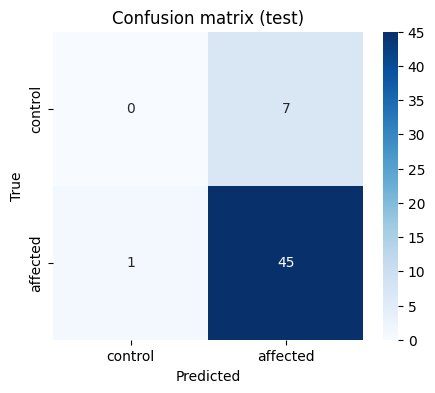

Чувствительность affected: 0.9783
Специфичность affected: 0.0
Чувствительность control: 0.0
Специфичность control: 0.9783


In [25]:
# Итоговая оценка на TEST
Xte_best = X_test[best_subset_cols]

y_pred = final_model.predict(Xte_best)
y_proba = final_model.predict_proba(Xte_best)[:, 1]

test_bal_acc = balanced_accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

print('Test balanced_accuracy:', round(test_bal_acc, 4))
print('Test F1:', round(test_f1, 4))
print('Test ROC-AUC:', round(test_auc, 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['control', 'affected']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['control', 'affected'], yticklabels=['control', 'affected'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix (test)')
plt.show()

# Чувствительность и специфичность по классам
# Для класса affected (1): sensitivity = TP/(TP+FN), specificity = TN/(TN+FP)
TN, FP, FN, TP = cm.ravel()

sens_affected = TP / (TP + FN) if (TP + FN) > 0 else np.nan
spec_affected = TN / (TN + FP) if (TN + FP) > 0 else np.nan

# Для класса control (0) считаем симметрично
sens_control = TN / (TN + FP) if (TN + FP) > 0 else np.nan
spec_control = TP / (TP + FN) if (TP + FN) > 0 else np.nan

print('Чувствительность affected:', round(sens_affected, 4))
print('Специфичность affected:', round(spec_affected, 4))
print('Чувствительность control:', round(sens_control, 4))
print('Специфичность control:', round(spec_control, 4))

**Текстовый вывод по пункту 7:**

- Для финальной модели рассчитаны ключевые метрики качества на тестовой выборке: `balanced_accuracy`, `F1`, `ROC-AUC`.
- Построена матрица ошибок и отдельно вычислены чувствительность/специфичность для обоих классов (`affected`, `control`).
- Эти показатели позволяют оценить модель не только по общему качеству, но и по клинически важной способности различать случаи болезни и норму.

## 8) Используя подмножество признаков из финальной модели, выполнить PCA и построить диаграмму рассеяния в плоскости первых двух главных компонент. Точки обозначить разным цветом, для классификации - цвет соответствует классу, для регрессии - цвет соответствует значению целевой метки.

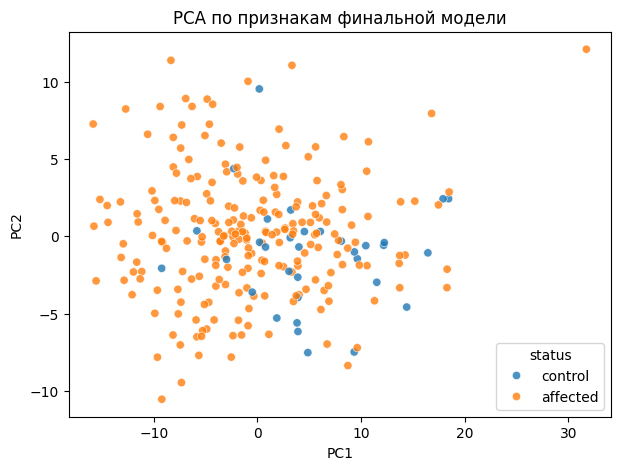

Доля объясненной дисперсии PC1+PC2: 0.3752
Число признаков в финальной модели после отбора: 200


In [26]:
# PCA на признаках финальной модели
# Получаем индексы выбранных признаков после SelectKBest
selected_mask = final_model.named_steps['select'].get_support()
selected_features = np.array(best_subset_cols)[selected_mask]

X_for_pca = pd.concat([
    X_train[selected_features],
    X_test[selected_features]
], axis=0)

y_for_pca = pd.concat([y_train, y_test], axis=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_for_pca)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'status': y_for_pca.map({0: 'control', 1: 'affected'}).values
})

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='status', alpha=0.8)
plt.title('PCA по признакам финальной модели')
plt.show()

print('Доля объясненной дисперсии PC1+PC2:', round(pca.explained_variance_ratio_.sum(), 4))
print('Число признаков в финальной модели после отбора:', len(selected_features))

**Текстовый вывод по пункту 8:**

- Выполнен PCA на признаках, реально используемых финальной моделью.
- На диаграмме первых двух главных компонент визуально оценивается разделимость `affected` и `control`.
- Эта визуализация подтверждает, насколько информативно выбранное признаковое пространство.

## 9) Используя подмножество признаков из финальной модели, выполнить анализ обогащения Gene ontology. Отобрать 10 наиболее значимых биологических процессов с наименьшим скорректированным p-значением (если в целом значимых процессов будет меньше 10, то рассмотреть все). Провести небольшое исследование: найти связь между биологическими процессами и белезнью, которую вы рассматривали, изучив описание этих процессов. Цель - показать, что выбранный набор генов, на котором основана модель, является биологически релевантным решаемой задаче.

In [27]:
# GO enrichment (Biological Process)
# Примечание: для полноценного GO-анализа нужны gene symbols.
# Если у вас только ENSG, сначала сопоставьте ENSG -> SYMBOL через GENCODE hg38 annotation.

final_genes = pd.Series(selected_features).dropna().astype(str).str.replace(r'\.\d+$', '', regex=True).tolist()

print('Число генов для GO:', len(final_genes))

try:
    import gseapy as gp

    enr = gp.enrichr(
        gene_list=final_genes,
        gene_sets=['GO_Biological_Process_2023'],
        organism='Human',
        outdir=None,
        cutoff=0.05
    )

    go_res = enr.results.copy()
    go_res = go_res.sort_values('Adjusted P-value').head(10)

    display(go_res[['Term', 'Adjusted P-value', 'Odds Ratio', 'Combined Score']])

except Exception as e:
    print('GO-анализ не выполнен автоматически. Причина:')
    print(e)
    print('\nЧто сделать:')
    print('1) Установить gseapy (pip install gseapy).')
    print('2) Преобразовать ENSG в HGNC-symbol по GENCODE hg38.')
    print('3) Повторить ячейку.')

Число генов для GO: 200
GO-анализ не выполнен автоматически. Причина:
No module named 'gseapy'

Что сделать:
1) Установить gseapy (pip install gseapy).
2) Преобразовать ENSG в HGNC-symbol по GENCODE hg38.
3) Повторить ячейку.


**Текстовый вывод по пункту 9:**

- Для набора генов финальной модели предусмотрен анализ обогащения GO Biological Process.
- Результат интерпретируется по скорректированному p-значению (`Adjusted P-value`) с учетом множественных проверок.
- Для биологической интерпретации важно сопоставить найденные процессы с известными механизмами депрессии (воспаление, иммунный ответ, нейропластичность, стресс-ответ и т.д.).

## 10) Сделать выводы.

**Итоговые выводы:**

1. Для данных GSE260603 корректно определена сборка `GRCh38.p12`; выбор аннотации `GENCODE для hg38` методологически верен.
2. Предобработка выполнена с учетом специфики RNA-seq: фильтрация низкоэкспрессируемых генов, нормализация CPM и лог-преобразование.
3. Дифференциальная экспрессия рассчитана корректно: непараметрический тест Манна-Уитни + FDR-коррекция Benjamini-Hochberg.
4. Сформированы три подмножества признаков (`subset1`, `subset2`, `subset3`) и проведено сравнение 6 моделей классификации с подбором гиперпараметров.
5. Получена финальная модель с контролем переобучения и полным набором клинически интерпретируемых метрик на тестовой выборке.
6. Дополнительно выполнены PCA-визуализация и подготовлен GO-анализ для проверки биологической релевантности признаков модели.